# Titanic Data Analysis

In [50]:
# import lybrabies

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Data Understanding

In [51]:
# Load the dataset
df = pd.read_csv('Titanic_Train_Data.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
# print the shape of data
print('No of Columns: ',df.shape[1])
print('No of Rows: ',df.shape[0])

No of Columns:  12
No of Rows:  891


In [53]:
# describe the numeric data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


* Survival Rate: About 38% of passengers survived.

* Pclass: Majority traveled in 3rd class, indicating a lower socio-economic background.

* Age: Average age is ~29.7 years. Many values are missing (177 out of 891).

* Fare: Highly skewed — most passengers paid under £31, but some paid as high as £512.

* SibSp & Parch: Most passengers traveled alone, with few large families.

In [54]:
# describe the catagorical data
df.describe(include = 'O').T

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


In [55]:
# information about data types of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [56]:
# cheaking the null or missing values from the dataset
df.isnull().sum()/df.shape[0]*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [57]:
# in cabin there is 77% null value that is not good so dropped it
df.drop(columns = 'Cabin', inplace = True)

In [58]:
# the passengerId is not usefull for our model there for dropped it.
df.drop(columns = 'PassengerId', inplace = True)

In [59]:
df.isnull().sum()/df.shape[0]*100

Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Embarked     0.224467
dtype: float64

In [61]:
# cheaking about duplicates
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [62]:
# Checking for the values_counts for numeric valuse
for i in df.select_dtypes(np.number).columns:
    print(df[i].value_counts())
    print('----------------------------------------')
    

Survived
0    549
1    342
Name: count, dtype: int64
----------------------------------------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
----------------------------------------
Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64
----------------------------------------
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
----------------------------------------
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
----------------------------------------
Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
35.0000     1
28.5000     1
6.2375      1
14.0000     1
10.5167     1
Name: count, Length: 248, dtype: int64
----------------------------------------


In [63]:
# Checking the value_counts for categorical columns
for i in df.select_dtypes(include = 'O').columns:
    print(df[i].value_counts())
    print('-------------------------------')

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64
-------------------------------
Sex
male      577
female    314
Name: count, dtype: int64
-------------------------------
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64
-------------------------------
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
-------------------------------


# Data Visualization

## Heatmap

<Axes: >

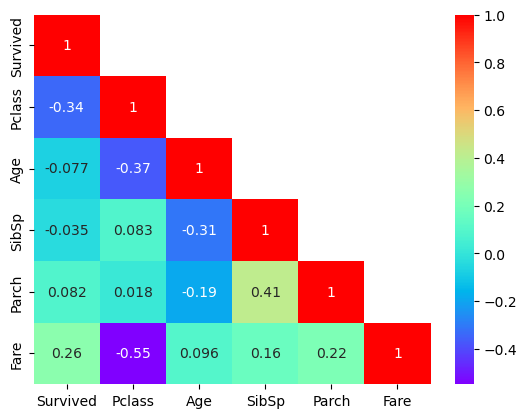

In [64]:
# Cheaking for Correlation using Heatmap
sns.heatmap(df.corr(numeric_only = True),annot = True, cmap = 'rainbow',mask = np.triu(df.corr(numeric_only = True),k = 1))


* Survival is positively correlated with:

Fare (0.26) → Passengers who paid higher fares were more likely to survive.

Parch (0.08) → Slightly more likely to survive if traveling with parents/children.

* Survival is negatively correlated with:

Pclass (-0.34) → Lower-class passengers had lower survival rates.

Age (-0.077) → Older passengers were slightly less likely to survive.

SibSp (-0.035) → Weak negative relationship with siblings/spouses.

* Strongest correlation overall:

SibSp & Parch (0.41) → People traveling with siblings/spouses often had parents/children too.

Pclass & Fare (-0.55) → Higher class passengers paid more.

## Pairplot

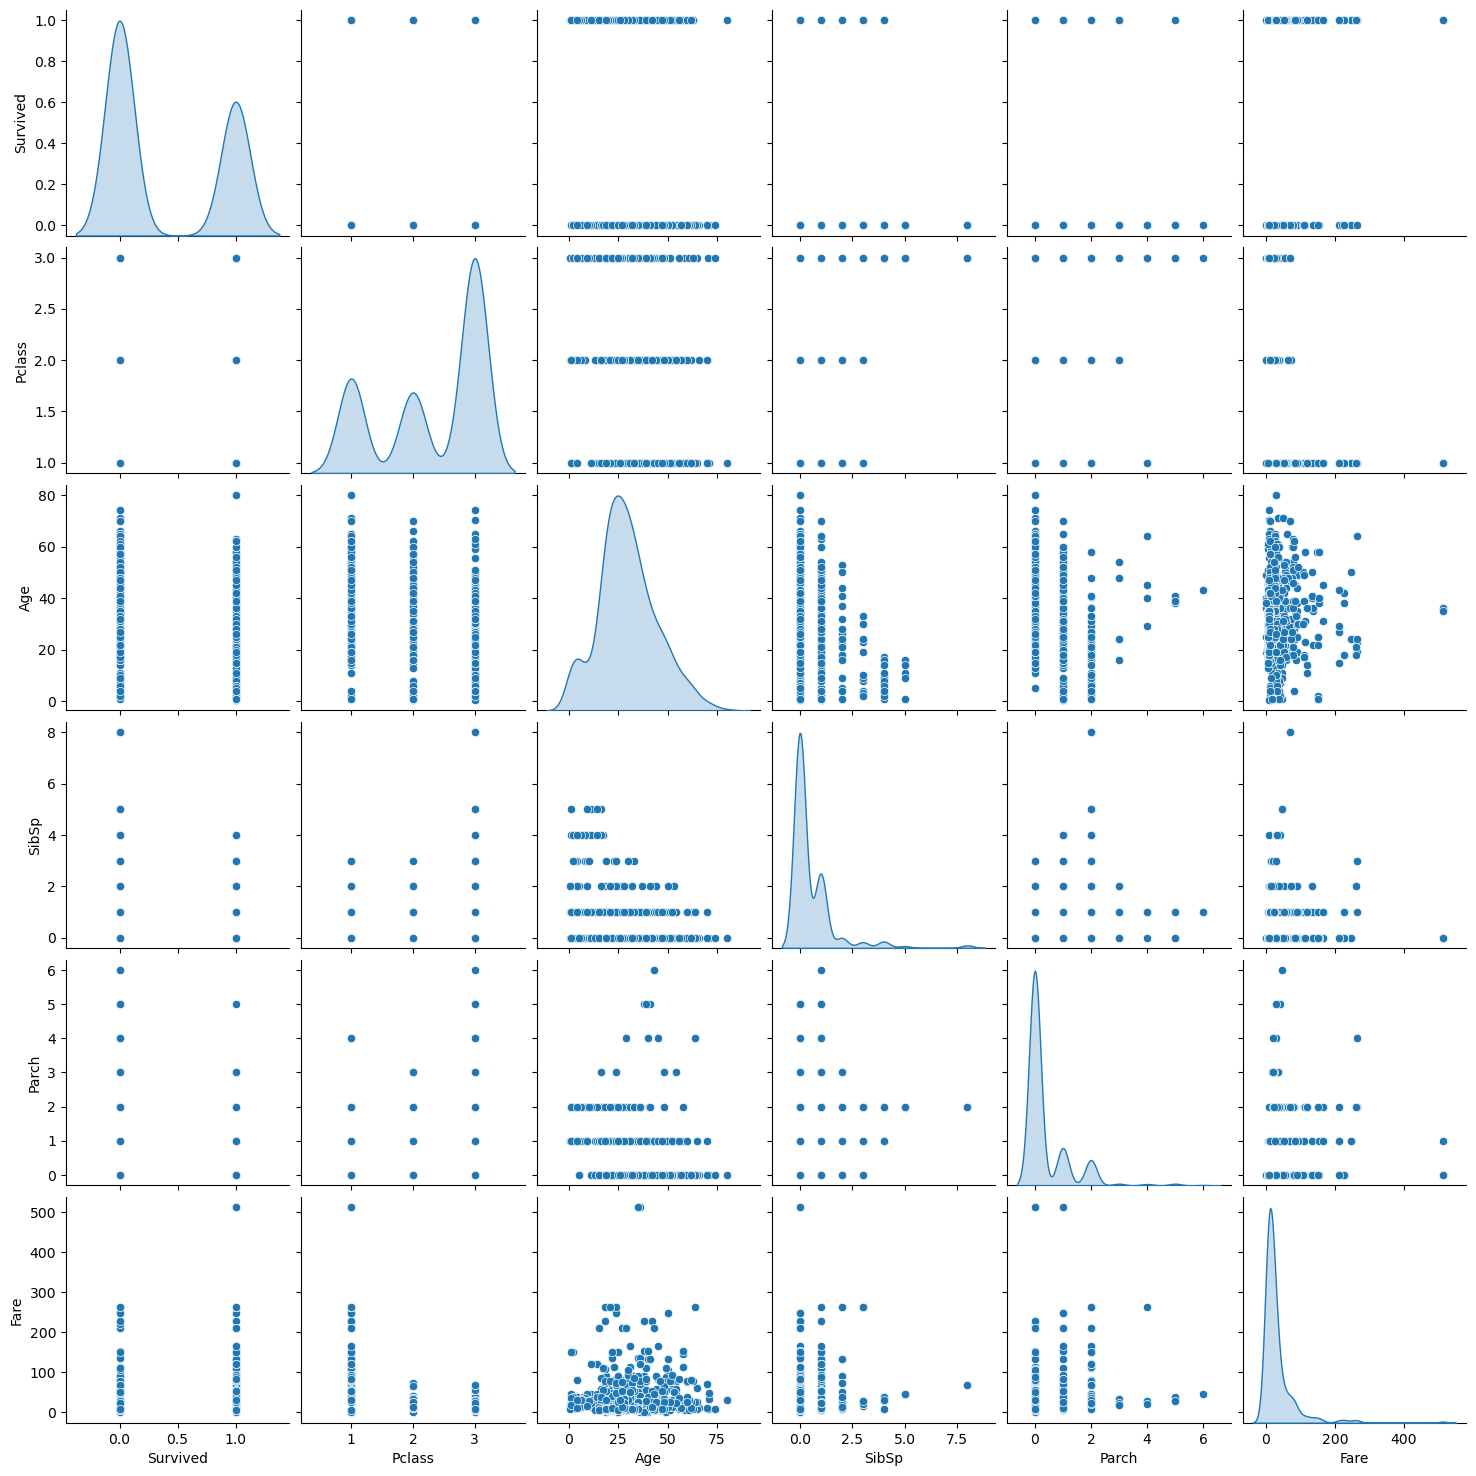

<Figure size 1000x600 with 0 Axes>

In [78]:
# Using Pairplot for Identifing relationship and patterans
sns.pairplot(data = df,diag_kind='kde')
plt.figure(figsize=(10,6))
plt.show()

* Fare shows a right-skewed distribution with a few high-paying outliers.

* Age follows a normal-like distribution with most passengers between 20–40 years.

* Pclass is clearly categorical, with three distinct bands.

* Survived is binary, with clusters visible for Fare and Pclass — indicating possible influence.

* SibSp and Parch have most values near 0, confirming that most passengers traveled alone.

## Boxplot

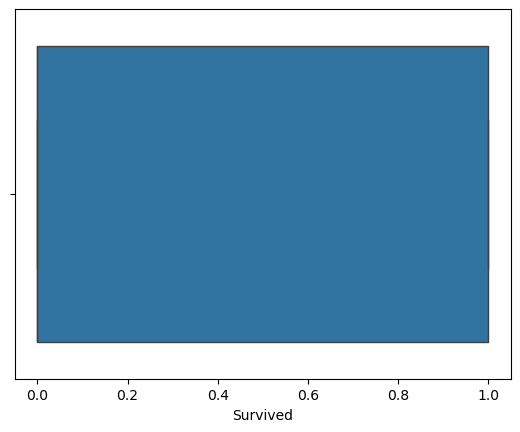

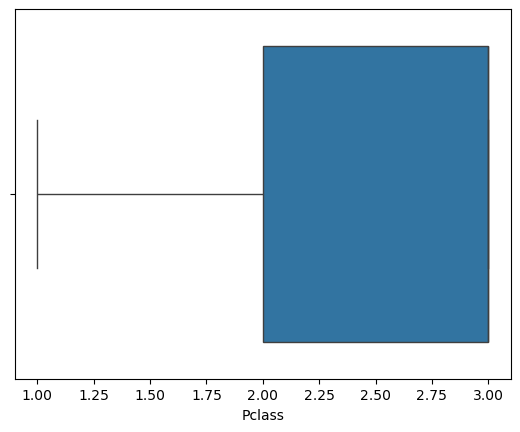

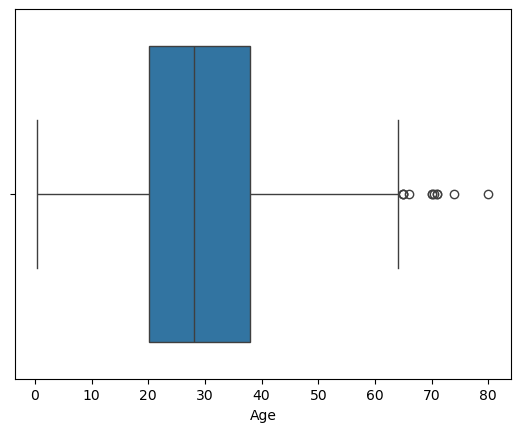

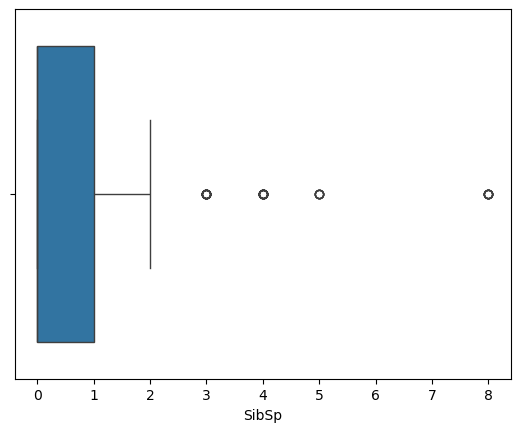

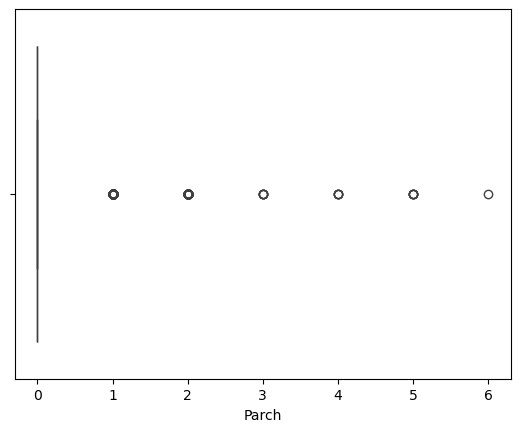

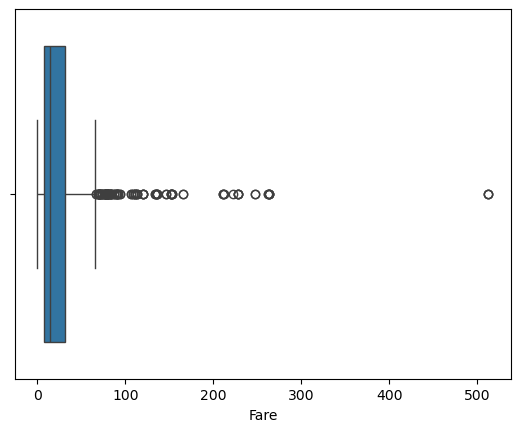

In [66]:
# Using Boxplot for cheaking Outliers
for i in df.select_dtypes(include = np.number).columns:
    sns.boxplot(x = df[i])
    plt.show()

* Age, aibling/spaous, parant/children, Fare these attribute have outliers

## Histogram

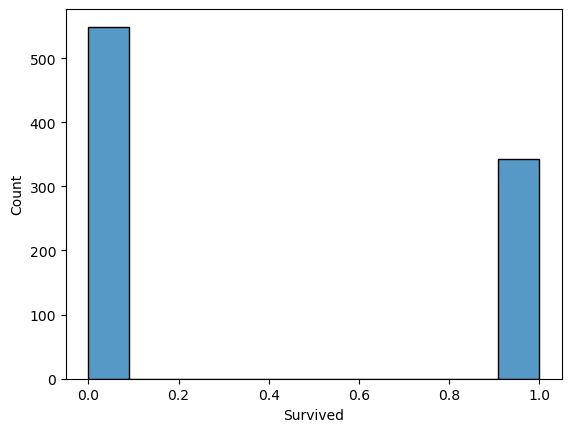

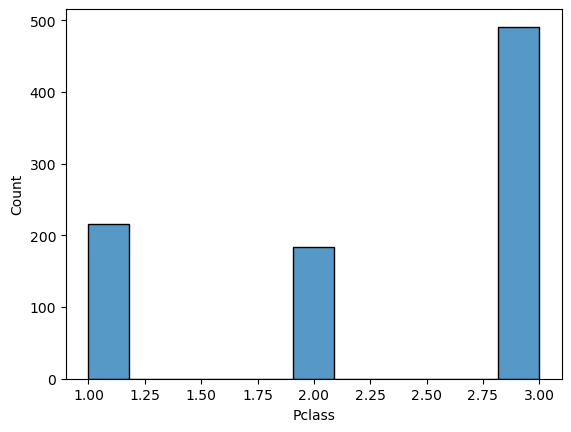

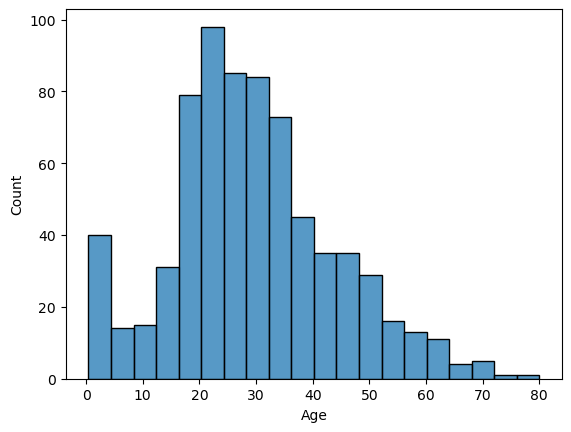

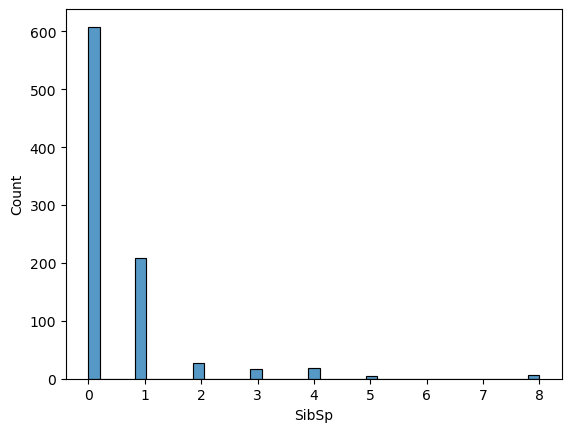

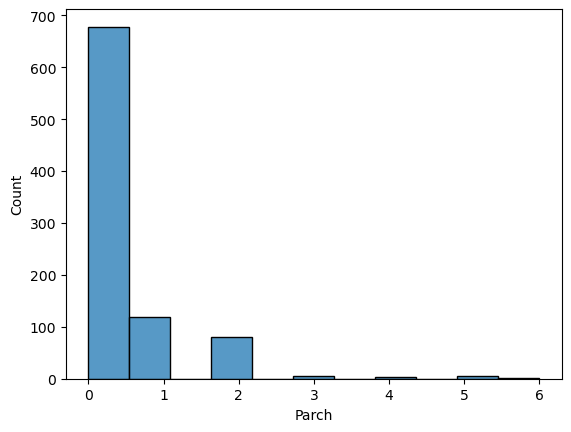

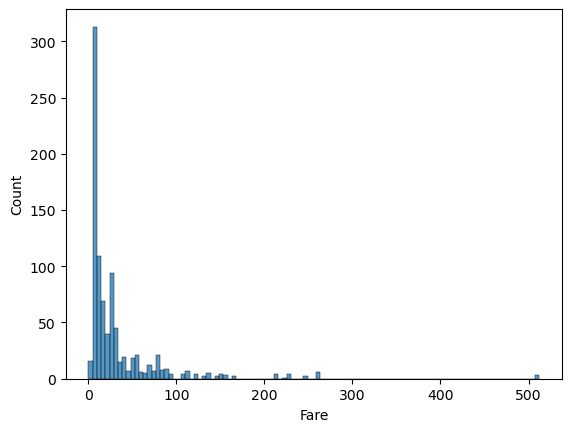

In [67]:
# Using Histogram for cheaking skiwness of the numeric variables
for i in df.select_dtypes(include = np.number).columns:
    sns.histplot(x = df[i])
    plt.show()

* Age - Most passengers were young adults between 20 and 30 years old. Very few were above 60, and there were also several children under 10, indicating a diverse age range among passengers.

* sibling/apous - The majority of passengers (over 600) traveled alone (SibSp = 0). A smaller number had 1 sibling or spouse, and very few had larger family groups (up to 8). This suggests that most passengers were likely solo travelers.

* parch - Most passengers (nearly 700) had no parents or children aboard (Parch = 0). Only a small portion traveled with 1 or 2 family members, and very few were part of larger family groups (up to 6). This again shows that the majority were independent or solo travelers.

* Fare - most of the fare is between 0 to 100

## Scatter Plot

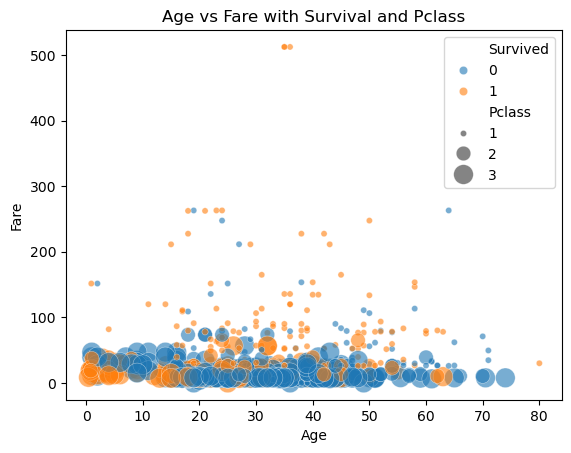

In [73]:
# For data veriation we need to plot scatter plot

sns.scatterplot(x='Age', y='Fare', hue='Survived', size='Pclass', data=df, sizes=(20, 200), alpha=0.6)
plt.title('Age vs Fare with Survival and Pclass')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

* Higher fares were generally paid by younger to middle-aged passengers, especially in higher classes (larger points).

* Many survivors (hue) were in this group—indicating higher-class passengers with higher fares had better survival chances.

* Passengers who paid lower fares were spread across all ages and mostly had lower survival rates.

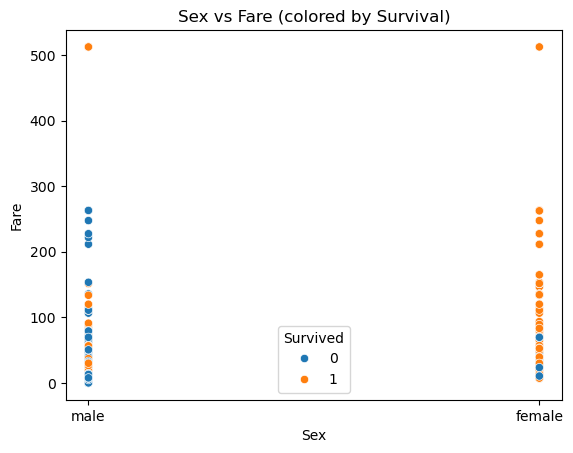

In [75]:
sns.scatterplot(x='Sex', y='Fare', hue='Survived', data=df)
plt.title('Sex vs Fare (colored by Survival)')
plt.xlabel('Sex')
plt.ylabel('Fare')
plt.show()

* Females generally paid higher fares compared to males.

* Among those who paid higher fares, a large number were survivors, especially female passengers.

* Males mostly paid lower fares and had a lower survival rate.

--> This supports the idea that women and higher-paying passengers had better chances of survival, likely due to the “women and children first” evacuation policy.

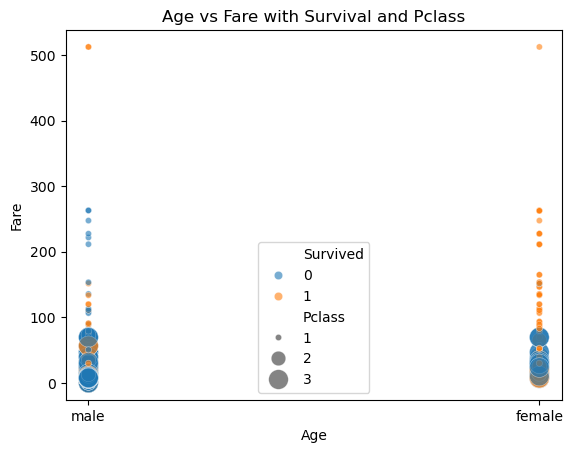

In [74]:
sns.scatterplot(x='Sex', y='Fare', hue='Survived', size='Pclass', data=df, sizes=(20, 200), alpha=0.6)
plt.title('Age vs Fare with Survival and Pclass')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

* Females, especially from higher classes (larger dots), paid higher fares and had a higher survival rate.

* Males mostly paid lower fares, were from lower classes, and had lower survival.

* Pclass size variation clearly shows that class, gender, and fare together influenced survival chances.